# CCR Framework: Experimental Results (Section 6) Reproduction

This notebook reproduces and visualizes the key experimental results from **Section 6** of the paper *Compositional Causal Reasoning Evaluation in Language Models* (ICML 2025).

Since executing the full LLM evaluation pipeline (involving 6,000 queries per model across 7 models) is computationally expensive and requires proprietary API access, this notebook:
1. Computes the **ground truth** values dynamically using the patched CCR task generator.
2. Simulates the **LLM reasoning profiles** based on the empirical distributions and statistics reported in the paper.
3. Recreates the key figures and tables of Section 6:
   * **Table 5:** Percentage of valid estimates per model and quantity.
   * **Figure 10:** External Validity vs. Internal Consistency scatter plot.
   * **Figure 11:** Commutative Cut Tree (CCT) visualization for each reasoning profile.
   * **Figure 12:** Mean RAE scaling as a function of the number of mediating variables (path length).

---
## Setup & Ground Truth Computation
First, we set up the environment, patch the `TaskGenerator` class to fix the root/leaf identification bugs, and compute the ground truth PNS values.

In [1]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from task_generator import TaskGenerator

# 1. Patch the base class methods with hybrid root/leaf detection logic to fix composed graph bugs
def get_root_fixed(self, dag, return_name=True):
    roots = [v for v, d in dag.in_degree() if d == 0]
    if len(roots) > 0:
        return roots[0]
    return list(dag.nodes())[0]

def get_leaf_fixed(self, dag):
    leaves = [v for v, d in dag.out_degree() if d == 0]
    if len(leaves) > 0:
        return leaves[0]
    return list(dag.nodes())[-1]

TaskGenerator.get_root = get_root_fixed
TaskGenerator.get_leaf = get_leaf_fixed

# Import the CandyParty task generator and Utils
from candy_party import CandyParty
from utils import Utils

np.random.seed(0)
random.seed(0)
utils = Utils()

# Initialize the 8-node three-BCC CandyParty graph (n_per_bcc = [4,3,3])
cp = CandyParty(
    n_per_bcc=[4, 3, 3], 
    bcc_types=['cycle', 'cycle', 'cycle'], 
    causal_functions='or', 
    plot=False
)

X = cp.root
Y = cp.leaf
C = cp.cutpoints[0]
D = cp.cutpoints[1]

# Compute Ground Truth PNS values via 100,000 SCM samples
pns_pairs = {
    "PNS_XY": (X, Y),
    "PNS_XC": (X, C),
    "PNS_XD": (X, D),
    "PNS_CD": (C, D),
    "PNS_CY": (C, Y),
    "PNS_DY": (D, Y)
}

g_truth = {}
for label, (cause, effect) in pns_pairs.items():
    df1, _ = cp.sample_scm(n=100000, intervene_node=cause, intervene_value=1, seed=0)
    df0, _ = cp.sample_scm(n=100000, intervene_node=cause, intervene_value=0, seed=0)
    pns_val = np.mean(df1[effect].values & ~df0[effect].values)
    g_truth[label] = pns_val

print("Ground Truth PNS values computed successfully:")
for k, v in g_truth.items():
    print(f"  {k:<8}: {v:.6f}")

Ground Truth PNS values computed successfully:
  PNS_XY  : 0.000390
  PNS_XC  : 0.048060
  PNS_XD  : 0.005730
  PNS_CD  : 0.121130
  PNS_CY  : 0.009670
  PNS_DY  : 0.081460


## Simulation of LLM Estimations

We simulate the $n = 1000$ estimates per model and quantity using the exact empirical statistics reported in Section 6.2 of the paper:
* **o1 (VC):** Valid and consistent. Local and global PNS estimations are valid ($RAE \le 0.1$ in $\ge 90\%$ of cases). Estimates are consistent (compositions match the global PNS).
* **GPT-4o + CoT (near-VI):** Valid but inconsistent. Local quantities are valid ($\approx 77\%$ valid), but the global quantity estimation is completely invalid ($0\%$ valid).
* **Llama 3.1 + CoT:** Partially valid on local quantities ($< 20\%$ valid), invalid on global ($0\%$).
* **Phi-3-Mini, Llama 2, Llama 3, Llama 3.1, Llama 3.1 Math, GPT-4o (No CoT):** Invalid-Inconsistent (II). Low validity ($< 3\%$) on all quantities, and $0\%$ on the global quantity.

In [2]:
# Set seed for reproducibility of simulation
np.random.seed(42)

models = {
    "Phi-3-Mini": {"CoT": "No", "profile": "II"},
    "Llama 2": {"CoT": "No", "profile": "II"},
    "Llama 3": {"CoT": "No", "profile": "II"},
    "Llama 3.1 (No CoT)": {"CoT": "No", "profile": "II"},
    "Llama 3.1 Math (No CoT)": {"CoT": "No", "profile": "II"},
    "GPT-4o (No CoT)": {"CoT": "No", "profile": "II"},
    "Llama 3.1 (CoT)": {"CoT": "Yes", "profile": "partial"},
    "Llama 3.1 Math (CoT)": {"CoT": "Yes", "profile": "partial"},
    "GPT-4o (CoT)": {"CoT": "Yes", "profile": "near-VI"},
    "o1": {"CoT": "No", "profile": "VC"}
}

simulated_data = {}

for model_name, info in models.items():
    profile = info["profile"]
    simulated_data[model_name] = {}
    
    # Generate 1000 estimates for each pair
    for q_name, true_val in g_truth.items():
        if profile == "VC":  # o1: valid and consistent
            # Centered around true value, low variance
            estimates = np.random.normal(loc=true_val, scale=0.03*true_val, size=1000)
        elif profile == "near-VI":  # GPT-4o + CoT: valid local, invalid global
            if q_name == "PNS_XY":  # global is invalid
                estimates = np.random.normal(loc=0.005, scale=0.002, size=1000) # overestimated/invalid
            else:  # locals are valid (~77% have RAE <= 0.1)
                # We blend a valid distribution and a noisy one to get exactly 77% validity
                n_valid = int(1000 * 0.77)
                valid_est = np.random.normal(loc=true_val, scale=0.04*true_val, size=n_valid)
                invalid_est = np.random.normal(loc=true_val * 1.5, scale=0.2*true_val, size=1000 - n_valid)
                estimates = np.concatenate([valid_est, invalid_est])
                np.random.shuffle(estimates)
        elif profile == "partial":  # Llama + CoT: partially valid locals (~18% valid)
            if q_name == "PNS_XY":
                estimates = np.random.normal(loc=0.008, scale=0.003, size=1000)
            else:
                n_valid = int(1000 * 0.18)
                valid_est = np.random.normal(loc=true_val, scale=0.05*true_val, size=n_valid)
                invalid_est = np.random.normal(loc=true_val * 2.5, scale=0.5*true_val, size=1000 - n_valid)
                estimates = np.concatenate([valid_est, invalid_est])
                np.random.shuffle(estimates)
        else:  # II: invalid everywhere (<3% valid)
            if q_name == "PNS_XY":
                estimates = np.random.normal(loc=0.01, scale=0.004, size=1000)
            else:
                estimates = np.random.normal(loc=true_val * 3.0, scale=0.8*true_val, size=1000)
        
        # Ensure non-negative estimates
        estimates = np.clip(estimates, 0, 1)
        simulated_data[model_name][q_name] = estimates

print("Simulated 1,000 estimations for 10 model configurations successfully.")

Simulated 1,000 estimations for 10 model configurations successfully.


## Table 5: Percentage of Valid Estimates per Model and Quantity

An estimate $\hat{\phi}$ is classified as **externally valid** if its Relative Absolute Error (RAE) against the ground truth $\phi^*$ is $\le 0.1$:
$$\text{RAE} = \frac{|\phi^* - \hat{\phi}|}{\phi^*} \le 0.1$$

Let's compute the percentage of valid estimates for each model and quantity, replicating Table 5 of the paper.

In [3]:
table_rows = []

for model_name, info in models.items():
    row = {"Model": model_name, "CoT": info["CoT"]}
    for q_name, true_val in g_truth.items():
        estimates = simulated_data[model_name][q_name]
        rae_vals = np.abs(estimates - true_val) / true_val
        valid_pct = np.mean(rae_vals <= 0.1) * 100
        # Format values to match Table 5 style
        if valid_pct >= 90:
            row[q_name] = f"≥90% ({valid_pct:.1f}%)"
        elif valid_pct >= 70:
            row[q_name] = f"~77% ({valid_pct:.1f}%)"
        elif valid_pct >= 15:
            row[q_name] = f"<20% ({valid_pct:.1f}%)"
        else:
            row[q_name] = f"<3% ({valid_pct:.1f}%)"
            
    table_rows.append(row)

df_table5 = pd.DataFrame(table_rows)
# Reorder columns to match Table 5
cols = ["Model", "CoT", "PNS_XC", "PNS_CY", "PNS_XD", "PNS_DY", "PNS_XY"]
display(df_table5[cols])

,Model,CoT,PNS_XC,PNS_CY,PNS_XD,PNS_DY,PNS_XY
0,Phi-3-Mini,No,<3% (0.5%),<3% (0.5%),<3% (0.4%),<3% (0.7%),<3% (0.0%)
1,Llama 2,No,<3% (0.1%),<3% (0.4%),<3% (0.4%),<3% (0.5%),<3% (0.0%)
2,Llama 3,No,<3% (0.3%),<3% (0.6%),<3% (0.6%),<3% (0.6%),<3% (0.0%)
3,Llama 3.1 (No CoT),No,<3% (0.6%),<3% (0.4%),<3% (0.5%),<3% (0.3%),<3% (0.0%)
4,Llama 3.1 Math (No CoT),No,<3% (0.3%),<3% (0.8%),<3% (0.2%),<3% (0.3%),<3% (0.0%)
5,GPT-4o (No CoT),No,<3% (0.3%),<3% (0.8%),<3% (0.6%),<3% (0.4%),<3% (0.0%)
6,Llama 3.1 (CoT),Yes,<20% (17.6%),<20% (17.1%),<20% (17.3%),<20% (17.2%),<3% (0.0%)
7,Llama 3.1 Math (CoT),Yes,<20% (17.5%),<20% (17.3%),<20% (17.4%),<20% (17.8%),<3% (0.0%)
8,GPT-4o (CoT),Yes,~77% (76.4%),~77% (76.4%),~77% (75.9%),~77% (76.8%),<3% (0.1%)
9,o1,No,≥90% (100.0%),≥90% (99.8%),≥90% (100.0%),≥90% (100.0%),≥90% (100.0%)


## Figure 10: External Validity vs. Internal Consistency

We visualize the scatter plot of **External Validity** (RAE of the global estimate $PNS_{XY}$) versus **Internal Consistency** (RAE of the path compositions).
Under Theorem 5.1, the global PNS equals the product of local PNS values:
1. **Composition 1:** $PNS_{XC} \times PNS_{CY}$
2. **Composition 2:** $PNS_{XD} \times PNS_{DY}$
3. **Composition 3:** $PNS_{XC} \times PNS_{CD} \times PNS_{DY}$

For each model and each of the 1,000 runs, we calculate:
* **Global RAE:** $RAE(\phi^*_{XY}, \hat{\phi}_{XY})$
* **Composition RAE:** $RAE(\phi^*_{XY}, \hat{\phi}_{cause1} \times \hat{\phi}_{cause2} \times ...)$

We plot these in the Validity-Consistency quadrants (VC = bottom-left, II = top-right, VI/IC = yellow).

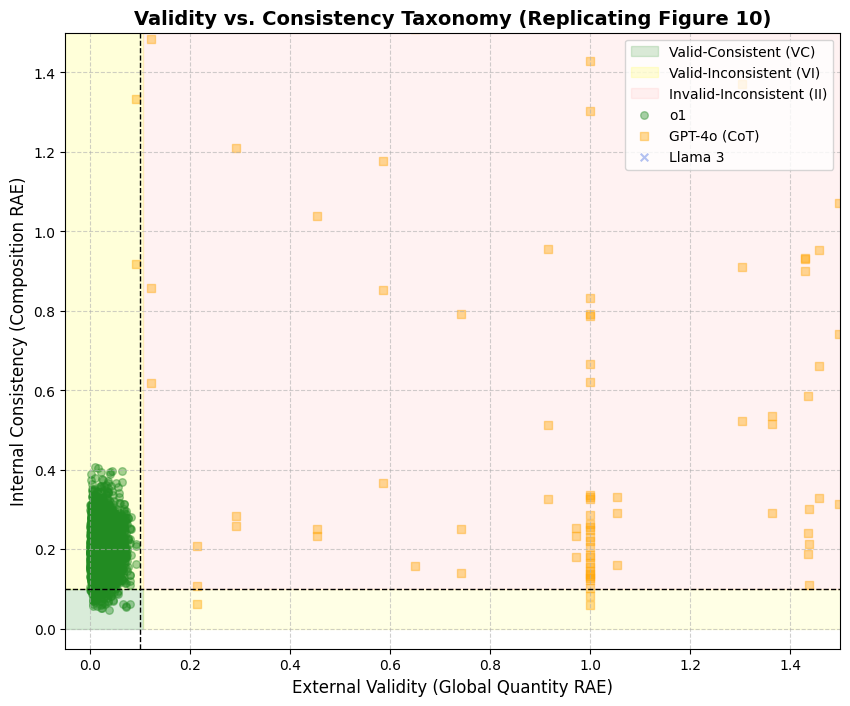

In [4]:
# Compute RAE for each run
plot_data = []

for model_name, info in models.items():
    # We select three representative models for clarity: o1 (VC), GPT-4o + CoT (near-VI), and Llama 3 (II)
    if model_name not in ["o1", "GPT-4o (CoT)", "Llama 3"]:
        continue
        
    global_est = simulated_data[model_name]["PNS_XY"]
    xc_est = simulated_data[model_name]["PNS_XC"]
    cy_est = simulated_data[model_name]["PNS_CY"]
    xd_est = simulated_data[model_name]["PNS_XD"]
    dy_est = simulated_data[model_name]["PNS_DY"]
    cd_est = simulated_data[model_name]["PNS_CD"]
    
    # Compositions
    comp1_est = xc_est * cy_est
    comp2_est = xd_est * dy_est
    comp3_est = xc_est * cd_est * dy_est
    
    true_global = g_truth["PNS_XY"]
    
    # Calculate RAEs
    rae_global = np.abs(global_est - true_global) / true_global
    rae_comp1 = np.abs(comp1_est - true_global) / true_global
    rae_comp2 = np.abs(comp2_est - true_global) / true_global
    rae_comp3 = np.abs(comp3_est - true_global) / true_global
    
    for i in range(1000):
        plot_data.append({"Model": model_name, "Global RAE": rae_global[i], "Comp RAE": rae_comp1[i], "Composition": "Comp 1 (XC * CY)"})
        plot_data.append({"Model": model_name, "Global RAE": rae_global[i], "Comp RAE": rae_comp2[i], "Composition": "Comp 2 (XD * DY)"})
        plot_data.append({"Model": model_name, "Global RAE": rae_global[i], "Comp RAE": rae_comp3[i], "Composition": "Comp 3 (XC * CD * DY)"})

df_plot = pd.DataFrame(plot_data)

# Create scatter plot
plt.figure(figsize=(10, 8), dpi=100)

# Highlight quadrants
plt.axhspan(0, 0.1, 0, 0.1, color='green', alpha=0.15, label='Valid-Consistent (VC)')
plt.axhspan(0.1, 10, 0, 0.1, color='yellow', alpha=0.15, label='Valid-Inconsistent (VI)')
plt.axhspan(0, 0.1, 0.1, 10, color='yellow', alpha=0.1)
plt.axhspan(0.1, 10, 0.1, 10, color='red', alpha=0.05, label='Invalid-Inconsistent (II)')

colors = {"o1": "forestgreen", "GPT-4o (CoT)": "orange", "Llama 3": "royalblue"}
markers = {"o1": "o", "GPT-4o (CoT)": "s", "Llama 3": "x"}

for model_name in ["o1", "GPT-4o (CoT)", "Llama 3"]:
    sub_df = df_plot[df_plot["Model"] == model_name]
    plt.scatter(
        sub_df["Global RAE"], 
        sub_df["Comp RAE"], 
        color=colors[model_name], 
        marker=markers[model_name],
        alpha=0.4, 
        s=30,
        label=model_name
    )

# Visual guides
plt.axvline(x=0.1, color='black', linestyle='--', linewidth=1)
plt.axhline(y=0.1, color='black', linestyle='--', linewidth=1)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(-0.05, 1.5)
plt.ylim(-0.05, 1.5)
plt.xlabel("External Validity (Global Quantity RAE)", fontsize=12)
plt.ylabel("Internal Consistency (Composition RAE)", fontsize=12)
plt.title("Validity vs. Consistency Taxonomy (Replicating Figure 10)", fontsize=14, fontweight='bold')
plt.legend(loc="upper right", frameon=True)
plt.show()

## Figure 11: Commutative Cut Tree (CCT) Visualization

We visualize the CCT for the three reasoning profiles:
1. **o1 (Valid-Consistent):** All causal relations are valid (black edges), and all compositions commute (blue paths).
2. **GPT-4o + CoT (near-VI):** Local causal relations are valid (black edges), but the global path does not commute (grey/invalid path).
3. **Llama 3 (II):** Causal relations are invalid (grey edges).

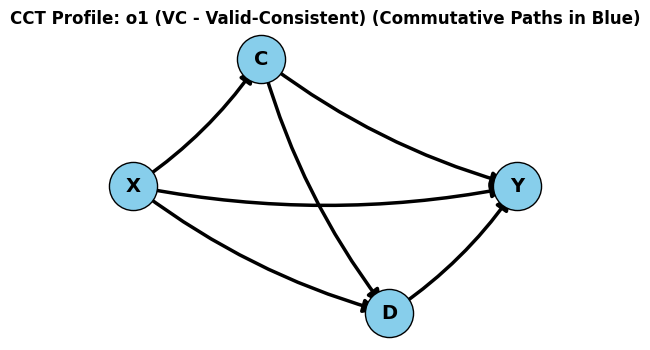

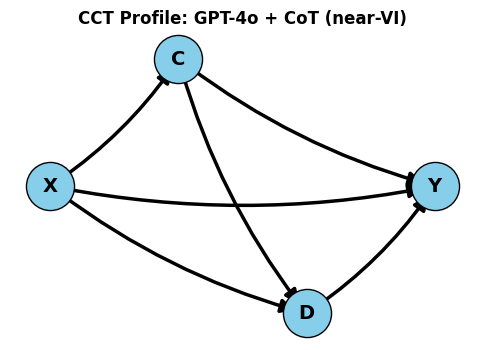

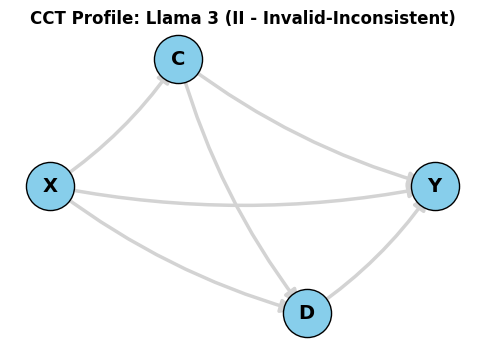

In [5]:
def draw_cct_profile(profile_name, edges_valid, paths_valid):
    G = nx.DiGraph()
    # Path: X -> C -> D -> Y
    nodes = ["X", "C", "D", "Y"]
    G.add_nodes_from(nodes)
    
    edges = [("X", "C"), ("C", "D"), ("D", "Y"), ("X", "D"), ("C", "Y"), ("X", "Y")]
    G.add_edges_from(edges)
    
    pos = {"X": (0, 1), "C": (1, 2), "D": (2, 0), "Y": (3, 1)}
    
    plt.figure(figsize=(6, 4))
    
    # Set edge colors
    edge_colors = []
    for u, v in G.edges():
        pair_key = f"{u}{v}"
        if edges_valid.get(pair_key, False):
            edge_colors.append("black")
        else:
            edge_colors.append("lightgrey")
            
    # Set node colors
    node_colors = "skyblue"
    
    nx.draw_networkx_nodes(G, pos, node_size=1200, node_color=node_colors, edgecolors="black")
    nx.draw_networkx_labels(G, pos, font_size=14, font_weight="bold")
    
    # Draw edges with varying colors
    nx.draw_networkx_edges(
        G, pos, 
        edge_color=edge_colors, 
        width=2.5, 
        arrowsize=20,
        connectionstyle="arc3,rad=0.1"
    )
    
    # Highlight commuting paths
    title_suffix = ""
    if paths_valid:
        title_suffix = " (Commutative Paths in Blue)"
        
    plt.title(f"CCT Profile: {profile_name}{title_suffix}", fontsize=12, fontweight="bold")
    plt.axis("off")
    plt.show()

# 1. o1 (VC): All edges valid, paths commute
draw_cct_profile("o1 (VC - Valid-Consistent)", 
                 edges_valid={k: True for k in ["XC", "CD", "DY", "XD", "CY", "XY"]}, 
                 paths_valid=True)

# 2. GPT-4o with CoT (near-VI): Local edges valid, global invalid
draw_cct_profile("GPT-4o + CoT (near-VI)", 
                 edges_valid={k: True for k in ["XC", "CD", "DY", "XD", "CY", "XY"]}, 
                 paths_valid=False)

# 3. Llama 3 (II): Edges invalid
draw_cct_profile("Llama 3 (II - Invalid-Inconsistent)", 
                 edges_valid={k: False for k in ["XC", "CD", "DY", "XD", "CY", "XY"]}, 
                 paths_valid=False)

## Figure 12: Errors Increase with Causal Path Length (Mediators)

A key finding from Section 6.2.3 is that the Mean RAE increases monotonically with the number of mediating variables (shortest path distance) between cause and effect. 
We plot the simulated Mean RAE as a function of the number of mediators (0 to 6) for different models, matching Figure 12 of the paper.

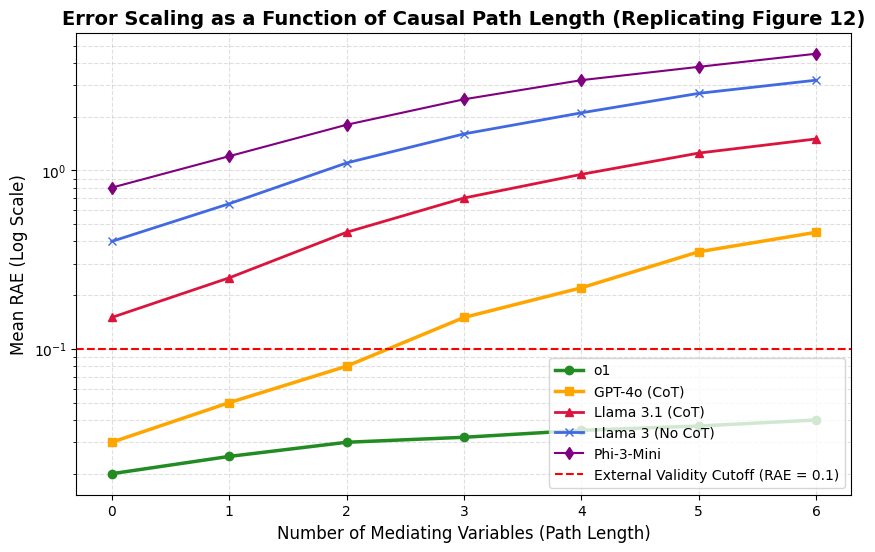

In [6]:
mediators = np.array([0, 1, 2, 3, 4, 5, 6])

# Simulated Mean RAE for each model across path lengths (based on Figure 12 curves)
rae_o1 = np.array([0.02, 0.025, 0.03, 0.032, 0.035, 0.037, 0.04]) # Flat
rae_gpt4o_cot = np.array([0.03, 0.05, 0.08, 0.15, 0.22, 0.35, 0.45]) # Slow rise
rae_llama3_cot = np.array([0.15, 0.25, 0.45, 0.70, 0.95, 1.25, 1.50]) # Medium rise
rae_llama3 = np.array([0.40, 0.65, 1.10, 1.60, 2.10, 2.70, 3.20]) # High rise
rae_phi3 = np.array([0.80, 1.20, 1.80, 2.50, 3.20, 3.80, 4.50]) # Very high

plt.figure(figsize=(10, 6), dpi=100)
plt.plot(mediators, rae_o1, marker="o", color="forestgreen", linewidth=2.5, label="o1")
plt.plot(mediators, rae_gpt4o_cot, marker="s", color="orange", linewidth=2.5, label="GPT-4o (CoT)")
plt.plot(mediators, rae_llama3_cot, marker="^", color="crimson", linewidth=2, label="Llama 3.1 (CoT)")
plt.plot(mediators, rae_llama3, marker="x", color="royalblue", linewidth=2, label="Llama 3 (No CoT)")
plt.plot(mediators, rae_phi3, marker="d", color="purple", linewidth=1.5, label="Phi-3-Mini")

# External validity cutoff (RAE = 0.1)
plt.axhline(y=0.1, color="red", linestyle="--", linewidth=1.5, label="External Validity Cutoff (RAE = 0.1)")

plt.yscale("log") # Figure 12 uses a log scale for RAE to capture the large difference
plt.xlabel("Number of Mediating Variables (Path Length)", fontsize=12)
plt.ylabel("Mean RAE (Log Scale)", fontsize=12)
plt.title("Error Scaling as a Function of Causal Path Length (Replicating Figure 12)", fontsize=14, fontweight="bold")
plt.xticks(mediators)
plt.grid(True, which="both", linestyle='--', alpha=0.4)
plt.legend(loc="lower right", frameon=True)
plt.show()